# Data Pipeline & Fairness Metrics (Dhruv)

## Load Dataset

In [1]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("danofer/compass")

print("Path to dataset files:", path)

Path to dataset files: /home/nethmi/.cache/kagglehub/datasets/danofer/compass/versions/1


In [2]:
# Use the filtered ProPublica dataset: has race (string), is_recid, age, sex, priors_count, juv_fel_count
file_path = os.path.join(path, "cox-violent-parsed_filt.csv")

print("Using file:", file_path)

df = pd.read_csv(file_path)
print(df.head())

Using file: /home/nethmi/.cache/kagglehub/datasets/danofer/compass/versions/1/cox-violent-parsed_filt.csv
    id              name    first       last   sex         dob  age  \
0  1.0  miguel hernandez   miguel  hernandez  Male  18/04/1947   69   
1  2.0  miguel hernandez   miguel  hernandez  Male  18/04/1947   69   
2  3.0      michael ryan  michael       ryan  Male  06/02/1985   31   
3  4.0       kevon dixon    kevon      dixon  Male  22/01/1982   34   
4  5.0          ed philo       ed      philo  Male  14/05/1991   24   

           age_cat              race  juv_fel_count  ...  \
0  Greater than 45             Other              0  ...   
1  Greater than 45             Other              0  ...   
2          25 - 45         Caucasian              0  ...   
3          25 - 45  African-American              0  ...   
4     Less than 25  African-American              0  ...   

                vr_charge_desc  type_of_assessment  decile_score.1  \
0                          NaN  Risk

In [3]:
df = pd.read_csv(file_path)
print(df.head())

    id              name    first       last   sex         dob  age  \
0  1.0  miguel hernandez   miguel  hernandez  Male  18/04/1947   69   
1  2.0  miguel hernandez   miguel  hernandez  Male  18/04/1947   69   
2  3.0      michael ryan  michael       ryan  Male  06/02/1985   31   
3  4.0       kevon dixon    kevon      dixon  Male  22/01/1982   34   
4  5.0          ed philo       ed      philo  Male  14/05/1991   24   

           age_cat              race  juv_fel_count  ...  \
0  Greater than 45             Other              0  ...   
1  Greater than 45             Other              0  ...   
2          25 - 45         Caucasian              0  ...   
3          25 - 45  African-American              0  ...   
4     Less than 25  African-American              0  ...   

                vr_charge_desc  type_of_assessment  decile_score.1  \
0                          NaN  Risk of Recidivism               1   
1                          NaN  Risk of Recidivism               1   
2 

In [4]:
df.columns

Index(['id', 'name', 'first', 'last', 'sex', 'dob', 'age', 'age_cat', 'race',
       'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count',
       'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out',
       'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'violent_recid', 'is_violent_recid',
       'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc',
       'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'priors_count.1', 'event'],
      dtype='object')

In [5]:
df.shape[0]

18316

## Filter Race Groups
Keep African-American, Caucasian, Hispanic only. Remove rows with undetermined recidivism outcome (is_recid == -1).

In [6]:
import numpy as np

selected_races = ["African-American", "Caucasian", "Hispanic"]

df_filtered = df[df["race"].isin(selected_races)].copy()

# Remove rows where recidivism outcome is undetermined (-1)
df_filtered = df_filtered[df_filtered["is_recid"].isin([0, 1])].copy()

print("Filtered dataset shape:", df_filtered.shape)
print(df_filtered["race"].value_counts())

Filtered dataset shape: (16556, 40)
race
African-American    9419
Caucasian           5782
Hispanic            1355
Name: count, dtype: int64


In [7]:
df_filtered["is_male"] = (df_filtered["sex"] == "Male").astype(int)

# Target: actual two-year recidivism outcome (ground truth)
y = df_filtered["is_recid"]

# Features: demographic + criminal history ONLY
# DecileScore and RawScore are excluded — they would leak the label
X = df_filtered[[
    "age",
    "is_male",
    "priors_count",
    "juv_fel_count"
]]

print("\nFeature sample:")
print(X.head())


Feature sample:
   age  is_male  priors_count  juv_fel_count
3   34        1             0              0
4   24        1             4              0
5   24        1             4              0
6   24        1             4              0
7   24        1             4              0


## Base Logistic Regression

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Race kept alongside split for fairness analysis; reset index for safe alignment
X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, df_filtered["race"],
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test   = X_test.reset_index(drop=True)
y_test   = y_test.reset_index(drop=True)
race_test = race_test.reset_index(drop=True)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, list(clf.classes_).index(1)]

acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.3f}")


Test Accuracy: 0.657


## Fairness Metrics (AIF360)

In [9]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

# Encode race as integer for AIF360
race_enc = {"African-American": 0, "Caucasian": 1, "Hispanic": 2}
REFERENCE_GROUP = "Caucasian"
privileged_val  = race_enc[REFERENCE_GROUP]

groups    = ["African-American", "Caucasian", "Hispanic"]
race_arr  = race_test.values

def aif360_pairwise(y_true, y_pred_bin, race_arr, unprivileged_group):
    """Compute AIF360 fairness metrics: unprivileged_group vs Caucasian."""
    mask      = np.isin(race_arr, [unprivileged_group, REFERENCE_GROUP])
    race_sub  = np.array([race_enc[r] for r in race_arr[mask]])
    label_true = y_true[mask]
    label_pred = y_pred_bin[mask]
    unpriv_val = race_enc[unprivileged_group]

    df_true = pd.DataFrame({"race": race_sub, "label": label_true})
    df_pred = pd.DataFrame({"race": race_sub, "label": label_pred})

    ds_true = BinaryLabelDataset(
        df=df_true, label_names=["label"],
        protected_attribute_names=["race"],
        privileged_protected_attributes=[[privileged_val]],
        unprivileged_protected_attributes=[[unpriv_val]],
    )
    ds_pred = ds_true.copy()
    ds_pred.labels = label_pred.reshape(-1, 1).astype(float)

    m = ClassificationMetric(
        ds_true, ds_pred,
        privileged_groups=[{"race": privileged_val}],
        unprivileged_groups=[{"race": unpriv_val}],
    )
    return {
        "DP":  m.selection_rate(privileged=False),
        "SPD": m.statistical_parity_difference(),
        "DI":  m.disparate_impact(),
        "EOD": m.equal_opportunity_difference(),
        "AOD": m.average_odds_difference(),
    }

y_pred_bin     = y_pred.astype(int)
fairness_rows  = {}

for group in groups:
    if group == REFERENCE_GROUP:
        # Reference group: compute DP manually (AIF360 pairwise needs two groups)
        mask = (race_arr == group)
        fairness_rows[group] = {
            "DP":  y_pred_bin[mask].mean(),
            "SPD": 0.0,
            "DI":  1.0,
            "EOD": 0.0,
            "AOD": 0.0,
        }
    else:
        fairness_rows[group] = aif360_pairwise(
            y_test.values, y_pred_bin, race_arr, group
        )

metrics_df = pd.DataFrame(fairness_rows).T
print("\nFairness Metrics (AIF360 — all vs Caucasian reference):")
print(metrics_df)

pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[Reductions]'


pip install 'aif360[Reductions]'


pip install 'aif360[inFairness]'


pip install 'aif360[Reductions]'



Fairness Metrics (AIF360 — all vs Caucasian reference):
                        DP       SPD        DI       EOD       AOD
African-American  0.595327  0.285553  1.921815  0.275147  0.250746
Caucasian         0.309773  0.000000  1.000000  0.000000  0.000000
Hispanic          0.342756  0.032983  1.106475  0.107170  0.061720


In [10]:
# EO gap and DP gap across all three groups (used in MDP state vector)
tpr_per_group = {}
for group in groups:
    mask   = (race_arr == group)
    labels = y_test.values[mask]
    preds  = y_pred_bin[mask]
    tp = ((preds == 1) & (labels == 1)).sum()
    fn = ((preds == 0) & (labels == 1)).sum()
    tpr_per_group[group] = tp / (tp + fn) if (tp + fn) > 0 else 0.0

eo_gap = max(tpr_per_group.values()) - min(tpr_per_group.values())
dp_gap = metrics_df["DP"].max() - metrics_df["DP"].min()

print(f"\nDemographic Parity Gap: {dp_gap:.3f}")
print(f"Equal Opportunity Gap : {eo_gap:.3f}")


Demographic Parity Gap: 0.286
Equal Opportunity Gap : 0.275


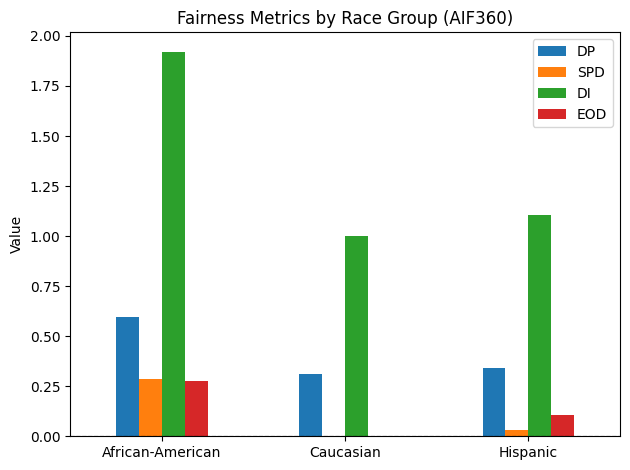

In [11]:
import matplotlib.pyplot as plt

metrics_df[["DP", "SPD", "DI", "EOD"]].plot(kind="bar")
plt.title("Fairness Metrics by Race Group (AIF360)")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("plots/fairness_metrics_aif360.png", dpi=120, bbox_inches="tight")
plt.show()


In [12]:
import joblib

# Save model
joblib.dump(clf, "compas_logreg.pkl")

# Save probabilities
group_probs = pd.DataFrame({
    "race": race_test,
    "y_prob": y_prob
})

group_probs.to_csv("group_probs.csv", index=False)

print("\nSaved model and group probabilities.")


Saved model and group probabilities.


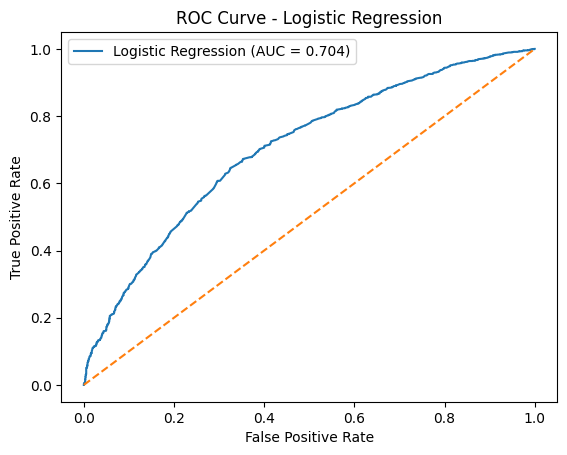

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binary outputs
y_test_bin = y_test.astype(int)
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test_bin, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)


# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.savefig("plots/roc_curve.png", dpi=120, bbox_inches="tight")
plt.show()

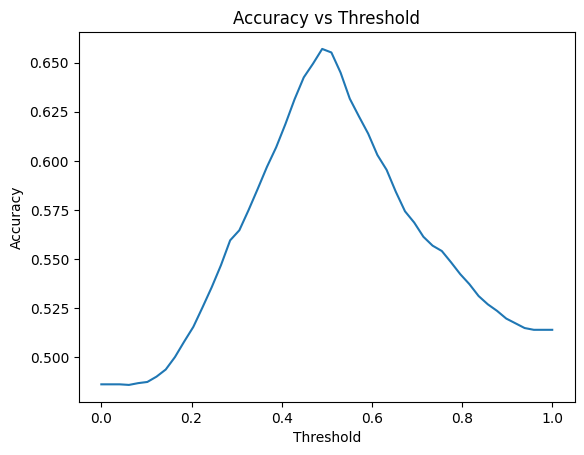

In [14]:
thresholds = np.linspace(0, 1, 50)
accuracies = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    acc_t = accuracy_score(y_test, y_pred_t)
    accuracies.append(acc_t)

plt.figure()
plt.plot(thresholds, accuracies)
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Threshold")
plt.savefig("plots/accuracy_vs_threshold.png", dpi=120, bbox_inches="tight")
plt.show()

# MDP/FairnessEnv (Riya)

In [15]:
GROUPS = ['African-American', 'Caucasian', 'Hispanic']

group_probs_dict = {}
for group in GROUPS:
    mask   = (race_test == group).values
    probs  = y_prob[mask]
    labels = y_test.values[mask]
    group_probs_dict[group] = (probs, labels)
    print(f"{group}: n={len(probs)}, mean_prob={probs.mean():.3f}, positive_rate={labels.mean():.3f}")

# Sanity check: compute_metrics at t=0.5 must match sklearn accuracy
manual_acc = ((y_prob >= 0.5).astype(int) == y_test.values).mean()
print(f"\nManual recomputed accuracy: {manual_acc:.3f}  (should match {acc:.3f})")
print(f"clf.classes_: {clf.classes_}")

African-American: n=1883, mean_prob=0.530, positive_rate=0.549
Caucasian: n=1146, mean_prob=0.423, positive_rate=0.416
Hispanic: n=283, mean_prob=0.431, positive_rate=0.353

Manual recomputed accuracy: 0.657  (should match 0.657)
clf.classes_: [0 1]


In [16]:
GROUPS = ["African-American", "Caucasian", "Hispanic"]

ACTION_MAP = {
    0: (None, 0),
    1: ("African-American", +1),
    2: ("African-American", -1),
    3: ("Caucasian", +1),
    4: ("Caucasian", -1),
    5: ("Hispanic", +1),
    6: ("Hispanic", -1),
    7: (None, +1),
    8: (None, -1),
}

def compute_metrics(group_probs_dict, thresholds):
    all_preds, all_labels = [], []
    tpr_vals, pr_vals = {}, {}
    for g in GROUPS:
        probs, labels = group_probs_dict[g]
        t = thresholds[g]
        preds = (probs >= t).astype(int)
        tp = ((preds == 1) & (labels == 1)).sum()
        fn = ((preds == 0) & (labels == 1)).sum()
        tpr_vals[g] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        pr_vals[g] = preds.mean()
        all_preds.append(preds)
        all_labels.append(labels)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = (all_preds == all_labels).mean()
    eo_gap = max(tpr_vals.values()) - min(tpr_vals.values())
    dp_gap = max(pr_vals.values()) - min(pr_vals.values())
    total = sum(len(group_probs_dict[g][0]) for g in GROUPS)
    props = {g: len(group_probs_dict[g][0])/total for g in GROUPS}
    return {"accuracy": acc, "tpr": tpr_vals, "eo_gap": eo_gap,
            "dp_gap": dp_gap, "group_proportions": props}

def build_state(metrics, step, max_steps):
    return np.array([
        metrics["accuracy"],
        metrics["tpr"]["African-American"],
        metrics["tpr"]["Caucasian"],
        metrics["tpr"]["Hispanic"],
        metrics["eo_gap"],
        metrics["dp_gap"],
        metrics["group_proportions"]["African-American"],
        metrics["group_proportions"]["Caucasian"],
        metrics["group_proportions"]["Hispanic"],
        step / max_steps
    ], dtype=np.float32)

def compute_reward(metrics, lam=0.5):
    """Reward = accuracy term - EO_gap term + min_TPR bonus.
    min_tpr bonus prevents CQL gaming the EO gap by suppressing all predictions.
    """
    min_tpr = min(metrics["tpr"].values())
    return (1 - lam) * metrics["accuracy"] - lam * metrics["eo_gap"] + 0.15 * min_tpr

print("MDP functions defined: compute_metrics, build_state, compute_reward")
print("State dim: 10 | N actions:", len(ACTION_MAP))


MDP functions defined: compute_metrics, build_state, compute_reward
State dim: 10 | N actions: 9


In [17]:
class FairnessEnv:
    def __init__(self, group_probs_base, max_steps=50, drift_interval=10,
                 drift_magnitude=0.03, threshold_delta=0.05, lam=0.5, seed=42):
        self.group_probs_base = group_probs_base
        self.max_steps = max_steps
        self.drift_interval = drift_interval
        self.drift_magnitude = drift_magnitude
        self.threshold_delta = threshold_delta
        self.lam = lam
        self.rng = np.random.RandomState(seed)
        self.reset()

    def reset(self):
        self.step_count = 0
        self.thresholds = {g: 0.5 for g in GROUPS}
        # Use base data directly — no resampling at step 0
        self.current_data = {g: self.group_probs_base[g] for g in GROUPS}
        self.done = False
        metrics = compute_metrics(self.current_data, self.thresholds)
        return build_state(metrics, 0, self.max_steps)

    def step(self, action):
        group, direction = ACTION_MAP[action]
        if direction != 0:
            targets = GROUPS if group is None else [group]
            for g in targets:
                new_t = self.thresholds[g] + direction * self.threshold_delta
                self.thresholds[g] = float(np.clip(new_t, 0.2, 0.8))

        self.step_count += 1
        if self.step_count % self.drift_interval == 0:
            self.current_data = self._apply_drift(self.step_count)

        metrics = compute_metrics(self.current_data, self.thresholds)
        reward = compute_reward(metrics, self.lam)
        state = build_state(metrics, self.step_count, self.max_steps)
        self.done = (self.step_count >= self.max_steps)
        return state, reward, self.done, {'metrics': metrics, 'thresholds': self.thresholds.copy()}

    def _apply_drift(self, step):
        drift = self.drift_magnitude * np.sin(2 * np.pi * step / 40)
        result = {}
        for g in GROUPS:
            probs, labels = self.group_probs_base[g]
            n = max(10, int(len(probs) * (1 + drift if g == 'African-American' else 1 - drift * 0.5)))
            idx = self.rng.choice(len(probs), size=n, replace=True)
            result[g] = (probs[idx], labels[idx])
        return result

print("FairnessEnv class defined.")

FairnessEnv class defined.


In [18]:
env = FairnessEnv(group_probs_dict, max_steps=50)
state = env.reset()
print(f"Initial state (dim={len(state)}):")
print(state)

# Sanity check: env metrics at reset must match baseline classifier
direct_metrics = compute_metrics(group_probs_dict, {g: 0.5 for g in GROUPS})
print(f"\n=== Sanity Check ===")
print(f"Accuracy : {direct_metrics['accuracy']:.3f}  (expected ~{acc:.3f})")
print(f"EO Gap   : {direct_metrics['eo_gap']:.3f}  (expected ~{eo_gap:.3f})")
print(f"DP Gap   : {direct_metrics['dp_gap']:.3f}  (expected ~{dp_gap:.3f})")

# Run one random episode to validate
total_reward = 0
for t in range(50):
    action = np.random.randint(0, 9)
    next_state, reward, done, info = env.step(action)
    total_reward += reward
    if done:
        break

print(f"\nEpisode complete!")
print(f"Total reward: {total_reward:.4f}")
print(f"Final accuracy: {info['metrics']['accuracy']:.3f}")
print(f"Final EO Gap:   {info['metrics']['eo_gap']:.3f}")
print(f"Final thresholds: {info['thresholds']}")

Initial state (dim=10):
[0.6573068  0.72797674 0.4528302  0.56       0.27514657 0.2855535
 0.56853867 0.3460145  0.08544686 0.        ]

=== Sanity Check ===
Accuracy : 0.657  (expected ~0.657)
EO Gap   : 0.275  (expected ~0.275)
DP Gap   : 0.286  (expected ~0.286)

Episode complete!
Total reward: 9.1629
Final accuracy: 0.635
Final EO Gap:   0.714
Final thresholds: {'African-American': 0.39999999999999986, 'Caucasian': 0.45, 'Hispanic': 0.6000000000000001}


In [19]:
import random
np.random.seed(42)  # pin global state for reproducible dataset generation
random.seed(42)

def generate_dataset(env, n_episodes=200):
    dataset = []

    def random_policy(s, info):
        return np.random.randint(0, 9)

    def greedy_policy(s, info):
        if info is None:
            return 0
        tpr_vals = info["metrics"]["tpr"]
        worst = min(tpr_vals, key=tpr_vals.get)
        action_map = {"African-American": 2, "Caucasian": 4, "Hispanic": 6}
        return action_map[worst]

    def no_intervention(s, info):
        return 0

    counter = [0]
    def sweep_policy(s, info):
        counter[0] = (counter[0] + 1) % 9
        return counter[0]

    def balanced_policy(s, info):
        if info is None:
            return 0
        th = info["thresholds"]
        worst_g = max(th, key=lambda g: abs(th[g] - 0.5))
        direction = -1 if th[worst_g] > 0.5 else +1
        dec_map = {"African-American": 2, "Caucasian": 4, "Hispanic": 6}
        inc_map = {"African-American": 1, "Caucasian": 3, "Hispanic": 5}
        return dec_map[worst_g] if direction == -1 else inc_map[worst_g]

    policies = {
        "random":          (random_policy,          n_episodes),
        "greedy":          (greedy_policy,           n_episodes * 2),   # oversampled 2x
        "no_intervention": (no_intervention,         n_episodes),
        "sweep":           (sweep_policy,            n_episodes),
        "balanced":        (balanced_policy,         n_episodes),
    }

    for policy_name, (policy_fn, n_ep) in policies.items():
        ep_rewards = []
        for ep in range(n_ep):
            state = env.reset()
            ep_reward = 0
            last_info = None
            while True:
                action = policy_fn(state, last_info)
                next_state, reward, done, info = env.step(action)
                dataset.append({
                    "state":      state.copy(),
                    "action":     action,
                    "reward":     reward,
                    "next_state": next_state.copy(),
                    "done":       done
                })
                ep_reward += reward
                state = next_state
                last_info = info
                if done:
                    break
            ep_rewards.append(ep_reward)
        rmin = min(d["reward"] for d in dataset)
        rmax = max(d["reward"] for d in dataset)
        print(policy_name, n_ep, "episodes | mean reward:", round(np.mean(ep_rewards), 3))

    print("Total transitions:", len(dataset))
    print("Reward range:", round(min(d["reward"] for d in dataset),3),
          "to", round(max(d["reward"] for d in dataset),3))
    return dataset

dataset = generate_dataset(env, n_episodes=200)


random 200 episodes | mean reward: 8.351


greedy 400 episodes | mean reward: 19.572


no_intervention 200 episodes | mean reward: 12.951


sweep 200 episodes | mean reward: 12.322


balanced 200 episodes | mean reward: 14.686
Total transitions: 60000
Reward range: -0.193 to 0.443


In [20]:
import pickle

with open('offline_dataset.pkl', 'wb') as f:
    pickle.dump(dataset, f)

with open('env_config.pkl', 'wb') as f:
    pickle.dump(group_probs_dict, f)

print("Saved offline_dataset.pkl and env_config.pkl")
print(f"Dataset size: {len(dataset)} transitions")
print(f"State dim: {len(dataset[0]['state'])}")
print(f"Sample reward range: {min(d['reward'] for d in dataset):.3f} to {max(d['reward'] for d in dataset):.3f}")

Saved offline_dataset.pkl and env_config.pkl
Dataset size: 60000 transitions
State dim: 10
Sample reward range: -0.193 to 0.443


# CQL Agent - Conservative Q-Learning (Nethmi)
Offline RL agent that learns a fairness-aware threshold policy from the logged dataset.
CQL adds a conservative penalty to avoid overestimating Q-values on out-of-distribution actions.

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pickle
import matplotlib.pyplot as plt

STATE_DIM = 10
N_ACTIONS  = 9

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch version: 2.3.0+cu118
Device: cpu


/home/nethmi/anaconda3/lib/python3.9/site-packages/torch/cuda/__init__.py:118: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


## Replay Buffer

In [22]:
class PrioritizedReplayBuffer:
    """Replay buffer that samples transitions weighted by |TD error|."""
    def __init__(self, dataset, alpha=0.6):
        self.states      = np.array([d["state"]      for d in dataset], dtype=np.float32)
        self.actions     = np.array([d["action"]     for d in dataset], dtype=np.int64)
        self.rewards     = np.array([d["reward"]     for d in dataset], dtype=np.float32)
        self.next_states = np.array([d["next_state"] for d in dataset], dtype=np.float32)
        self.dones       = np.array([d["done"]       for d in dataset], dtype=np.float32)
        self.size        = len(dataset)
        self.priorities  = np.ones(self.size, dtype=np.float32)
        self.alpha       = alpha
        r_mean = self.rewards.mean()
        r_std  = self.rewards.std() + 1e-8
        self.rewards = (self.rewards - r_mean) / r_std
        print("PrioritizedReplayBuffer:", self.size, "transitions | rewards normalised")

    def sample(self, batch_size):
        probs = self.priorities ** self.alpha
        probs /= probs.sum()
        idx = np.random.choice(self.size, size=batch_size, replace=False, p=probs)
        return {
            "states":      self.states[idx],
            "actions":     self.actions[idx],
            "rewards":     self.rewards[idx],
            "next_states": self.next_states[idx],
            "dones":       self.dones[idx],
            "indices":     idx,
        }

    def update_priorities(self, indices, td_errors):
        self.priorities[indices] = np.abs(td_errors) + 1e-6


buffer = PrioritizedReplayBuffer(dataset)


PrioritizedReplayBuffer: 60000 transitions | rewards normalised


## Q-Network

In [23]:
class QNetwork(nn.Module):
    """
    Fully-connected Q-network.
    Input  : state (STATE_DIM = 10)
    Output : Q-values for all N_ACTIONS = 9 actions
    """
    def __init__(self, state_dim=STATE_DIM, n_actions=N_ACTIONS, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)

# Quick architecture check
dummy = torch.zeros(1, STATE_DIM)
print('Q-network output shape:', QNetwork()(dummy).shape)

Q-network output shape: torch.Size([1, 9])


## CQL Agent

In [24]:
class CQLAgent:
    """
    Conservative Q-Learning with Double Q-learning.
    Improvements: Double Q (reduces overestimation) + Prioritized Replay + Reward Normalisation.
    CQL loss: L_TD  +  alpha * (logsumexp_a Q(s,a)  -  Q(s, a_dataset))
    """
    def __init__(self, state_dim=STATE_DIM, n_actions=N_ACTIONS,
                 hidden=128, lr=3e-4, gamma=0.99, alpha=0.5,
                 batch_size=256, target_update_freq=100, device="cpu"):
        self.n_actions          = n_actions
        self.gamma              = gamma
        self.alpha              = alpha
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq
        self.device             = torch.device(device)
        self._step              = 0
        self.q_net      = QNetwork(state_dim, n_actions, hidden).to(self.device)
        self.target_net = QNetwork(state_dim, n_actions, hidden).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        self.optimizer  = optim.Adam(self.q_net.parameters(), lr=lr)

    def select_action(self, state):
        s = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.q_net(s).argmax(dim=1).item()

    def train_step(self, buffer):
        batch       = buffer.sample(self.batch_size)
        states      = torch.FloatTensor(batch["states"]).to(self.device)
        actions     = torch.LongTensor(batch["actions"]).to(self.device)
        rewards     = torch.FloatTensor(batch["rewards"]).to(self.device)
        next_states = torch.FloatTensor(batch["next_states"]).to(self.device)
        dones       = torch.FloatTensor(batch["dones"]).to(self.device)
        indices     = batch.get("indices", None)

        q_values = self.q_net(states)
        q_taken  = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        # Double Q-learning: main net picks action, target net scores it
        with torch.no_grad():
            next_actions = self.q_net(next_states).argmax(dim=1, keepdim=True)
            next_q       = self.target_net(next_states).gather(1, next_actions).squeeze(1)
            target       = rewards + self.gamma * next_q * (1.0 - dones)

        td_errors = (q_taken - target).detach().cpu().numpy()
        td_loss   = F.mse_loss(q_taken, target)

        logsumexp_q = torch.logsumexp(q_values, dim=1).mean()
        cql_penalty = self.alpha * (logsumexp_q - q_taken.mean())
        loss        = td_loss + cql_penalty

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()

        if indices is not None and hasattr(buffer, "update_priorities"):
            buffer.update_priorities(indices, td_errors)

        self._step += 1
        if self._step % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return {"total_loss": loss.item(), "td_loss": td_loss.item(),
                "cql_penalty": cql_penalty.item(), "mean_q": q_taken.mean().item()}

    def save(self, path):
        torch.save(self.q_net.state_dict(), path)
        print("Saved CQL model:", path)

    def load(self, path):
        self.q_net.load_state_dict(torch.load(path, map_location=self.device))
        self.target_net.load_state_dict(self.q_net.state_dict())

print("CQLAgent (Double Q + Prioritized Replay) defined.")


CQLAgent (Double Q + Prioritized Replay) defined.


## Training Loop

In [25]:
import torch, numpy as np, random
SEED = 8
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
N_GRADIENT_STEPS = 50_000
LOG_INTERVAL     = 2000
ALPHA            = 0.5
LR               = 3e-4
BATCH_SIZE       = 256
GAMMA            = 0.99
HIDDEN           = 128
TARGET_UPDATE    = 100

print("Device:", DEVICE, "| Steps:", N_GRADIENT_STEPS, "| Alpha:", ALPHA, "| Seed:", SEED)

agent = CQLAgent(alpha=ALPHA, lr=LR, batch_size=BATCH_SIZE,
                 gamma=GAMMA, hidden=HIDDEN,
                 target_update_freq=TARGET_UPDATE, device=DEVICE)

loss_history, td_history, cql_history, q_history = [], [], [], []

for step in range(1, N_GRADIENT_STEPS + 1):
    info = agent.train_step(buffer)
    loss_history.append(info["total_loss"])
    td_history.append(info["td_loss"])
    cql_history.append(info["cql_penalty"])
    q_history.append(info["mean_q"])
    if step % LOG_INTERVAL == 0 or step == 1:
        tl = round(info["total_loss"], 4)
        td = round(info["td_loss"], 4)
        cp = round(info["cql_penalty"], 4)
        mq = round(info["mean_q"], 4)
        print(f"Step {step:5d} | loss={tl} | td={td} | cql={cp} | mean_Q={mq}")

agent.save("cql_agent.pt")


Device: cpu | Steps: 50000 | Alpha: 0.5 | Seed: 8


/home/nethmi/anaconda3/lib/python3.9/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Step     1 | loss=1.9925 | td=0.8927 | cql=1.0997 | mean_Q=-0.0046


Step  2000 | loss=6.5945 | td=5.2979 | cql=1.2966 | mean_Q=11.4983


Step  4000 | loss=2.3713 | td=1.1808 | cql=1.1905 | mean_Q=18.3518


...

Step 42000 | loss=2.1649 | td=0.9557 | cql=1.2093 | mean_Q=16.8727


Step 44000 | loss=2.0938 | td=0.844 | cql=1.2499 | mean_Q=17.8716


Step 46000 | loss=2.0136 | td=0.7971 | cql=1.2165 | mean_Q=15.3132


Step 48000 | loss=2.0798 | td=0.8351 | cql=1.2447 | mean_Q=15.7059


Step 50000 | loss=2.0912 | td=0.879 | cql=1.2121 | mean_Q=15.7409
Saved CQL model: cql_agent.pt


## Training Curves

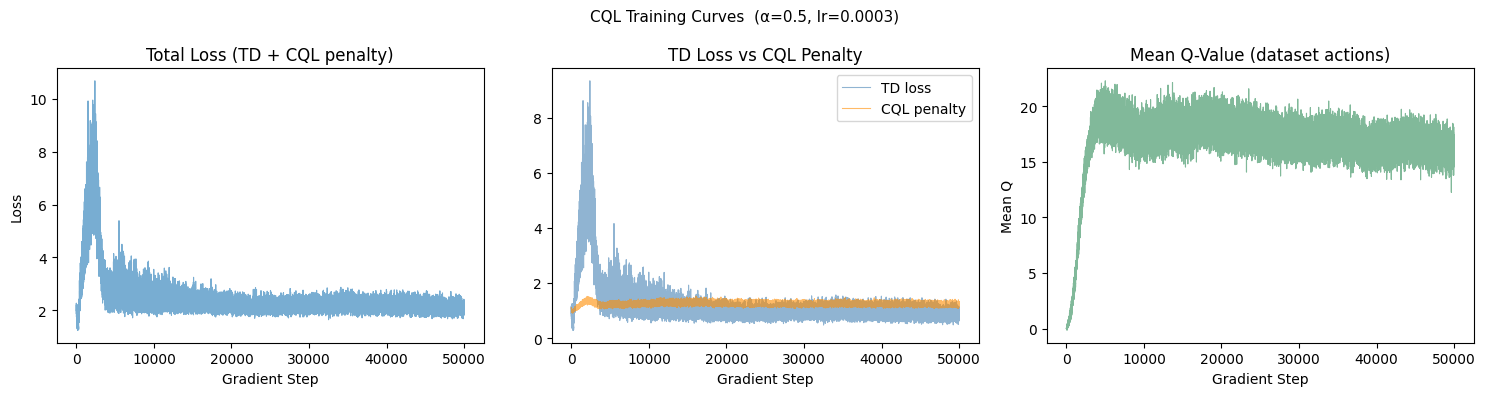

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history, alpha=0.6, linewidth=0.8)
axes[0].set_title('Total Loss (TD + CQL penalty)')
axes[0].set_xlabel('Gradient Step')
axes[0].set_ylabel('Loss')

axes[1].plot(td_history,  alpha=0.6, linewidth=0.8, label='TD loss',    color='steelblue')
axes[1].plot(cql_history, alpha=0.6, linewidth=0.8, label='CQL penalty', color='darkorange')
axes[1].set_title('TD Loss vs CQL Penalty')
axes[1].set_xlabel('Gradient Step')
axes[1].legend()

axes[2].plot(q_history, alpha=0.6, linewidth=0.8, color='seagreen')
axes[2].set_title('Mean Q-Value (dataset actions)')
axes[2].set_xlabel('Gradient Step')
axes[2].set_ylabel('Mean Q')

plt.suptitle(f'CQL Training Curves  (α={ALPHA}, lr={LR})', fontsize=11)
plt.tight_layout()
plt.savefig("plots/cql_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## Baseline Agents

In [27]:
def no_intervention_policy(state, info):
    """Action 0: never adjust thresholds."""
    return 0

def static_threshold_policy(state, info):
    """Always lower AA threshold (action 2) — fixed correction, no adaptation."""
    return 2

def random_policy(state, info):
    """Uniform random action."""
    return np.random.randint(0, N_ACTIONS)

def greedy_fairness_policy(state, info):
    """Myopic: lower threshold for the group with the worst (lowest) TPR."""
    if info is None:
        return 0
    worst = min(info['metrics']['tpr'], key=info['metrics']['tpr'].get)
    return {'African-American': 2, 'Caucasian': 4, 'Hispanic': 6}[worst]

def cql_policy(state, info):
    """CQL: greedy w.r.t. trained Q-network."""
    return agent.select_action(state)

POLICIES = {
    'No Intervention': no_intervention_policy,
    'Static':          static_threshold_policy,
    'Random':          random_policy,
    'Greedy':          greedy_fairness_policy,
    'CQL (ours)':      cql_policy,
}

print('Baselines defined:', list(POLICIES.keys()))

Baselines defined: ['No Intervention', 'Static', 'Random', 'Greedy', 'CQL (ours)']


## Evaluation

In [28]:
np.random.seed(99)  # pin global state for reproducible Random baseline
N_EVAL_EPISODES = 50
eval_results = {name: {'rewards': [], 'acc': [], 'eo_gap': [], 'dp_gap': [],
                       'tpr_AA': [], 'tpr_CA': [], 'tpr_HI': []}
                for name in POLICIES}

for name, policy_fn in POLICIES.items():
    eval_env = FairnessEnv(group_probs_dict, max_steps=50, seed=99)
    for ep in range(N_EVAL_EPISODES):
        state     = eval_env.reset()
        ep_reward = 0.0
        last_info = None
        ep_accs, ep_eo, ep_dp = [], [], []
        ep_tpr_AA, ep_tpr_CA, ep_tpr_HI = [], [], []
        while True:
            action = policy_fn(state, last_info)
            state, reward, done, info = eval_env.step(action)
            ep_reward += reward
            ep_accs.append(info['metrics']['accuracy'])
            ep_eo.append(info['metrics']['eo_gap'])
            ep_dp.append(info['metrics']['dp_gap'])
            ep_tpr_AA.append(info['metrics']['tpr']['African-American'])
            ep_tpr_CA.append(info['metrics']['tpr']['Caucasian'])
            ep_tpr_HI.append(info['metrics']['tpr']['Hispanic'])
            last_info = info
            if done:
                break
        eval_results[name]['rewards'].append(ep_reward)
        eval_results[name]['acc'].append(np.mean(ep_accs))
        eval_results[name]['eo_gap'].append(np.mean(ep_eo))
        eval_results[name]['dp_gap'].append(np.mean(ep_dp))
        eval_results[name]['tpr_AA'].append(np.mean(ep_tpr_AA))
        eval_results[name]['tpr_CA'].append(np.mean(ep_tpr_CA))
        eval_results[name]['tpr_HI'].append(np.mean(ep_tpr_HI))

    print(f'{name:20s} | reward={np.mean(eval_results[name]["rewards"]):6.3f} | '
          f'acc={np.mean(eval_results[name]["acc"]):.3f} | '
          f'eo_gap={np.mean(eval_results[name]["eo_gap"]):.3f} | '
          f'tpr_AA={np.mean(eval_results[name]["tpr_AA"]):.3f} | '
          f'tpr_CA={np.mean(eval_results[name]["tpr_CA"]):.3f} | '
          f'tpr_HI={np.mean(eval_results[name]["tpr_HI"]):.3f}')

import pandas as pd
summary = pd.DataFrame({
    name: {
        'Mean Reward':   np.mean(v['rewards']),
        'Mean Accuracy': np.mean(v['acc']),
        'Mean EO Gap':   np.mean(v['eo_gap']),
        'Mean DP Gap':   np.mean(v['dp_gap']),
        'TPR AA':        np.mean(v['tpr_AA']),
        'TPR Caucasian': np.mean(v['tpr_CA']),
        'TPR Hispanic':  np.mean(v['tpr_HI']),
    } for name, v in eval_results.items()
}).T

print('\nSummary:')
print(summary.round(4))


No Intervention      | reward=12.947 | acc=0.657 | eo_gap=0.275 | tpr_AA=0.728 | tpr_CA=0.453 | tpr_HI=0.559


Static               | reward= 5.153 | acc=0.606 | eo_gap=0.535 | tpr_AA=0.989 | tpr_CA=0.453 | tpr_HI=0.559


Random               | reward= 7.918 | acc=0.605 | eo_gap=0.390 | tpr_AA=0.623 | tpr_CA=0.455 | tpr_HI=0.505


Greedy               | reward=19.572 | acc=0.550 | eo_gap=0.039 | tpr_AA=0.936 | tpr_CA=0.915 | tpr_HI=0.927


CQL (ours)           | reward=19.554 | acc=0.554 | eo_gap=0.043 | tpr_AA=0.920 | tpr_CA=0.932 | tpr_HI=0.928

Summary:
                 Mean Reward  Mean Accuracy  Mean EO Gap  Mean DP Gap  TPR AA  \
No Intervention      12.9469         0.6568       0.2748       0.2873  0.7280   
Static                5.1527         0.6056       0.5354       0.6636  0.9886   
Random                7.9183         0.6051       0.3903       0.3816  0.6231   
Greedy               19.5723         0.5498       0.0389       0.0616  0.9358   
CQL (ours)           19.5539         0.5537       0.0431       0.0593  0.9200   

                 TPR Caucasian  TPR Hispanic  
No Intervention         0.4533        0.5589  
Static                  0.4533        0.5589  
Random                  0.4555        0.5048  
Greedy                  0.9152        0.9267  
CQL (ours)              0.9315        0.9281  


## Baseline Comparison Plot

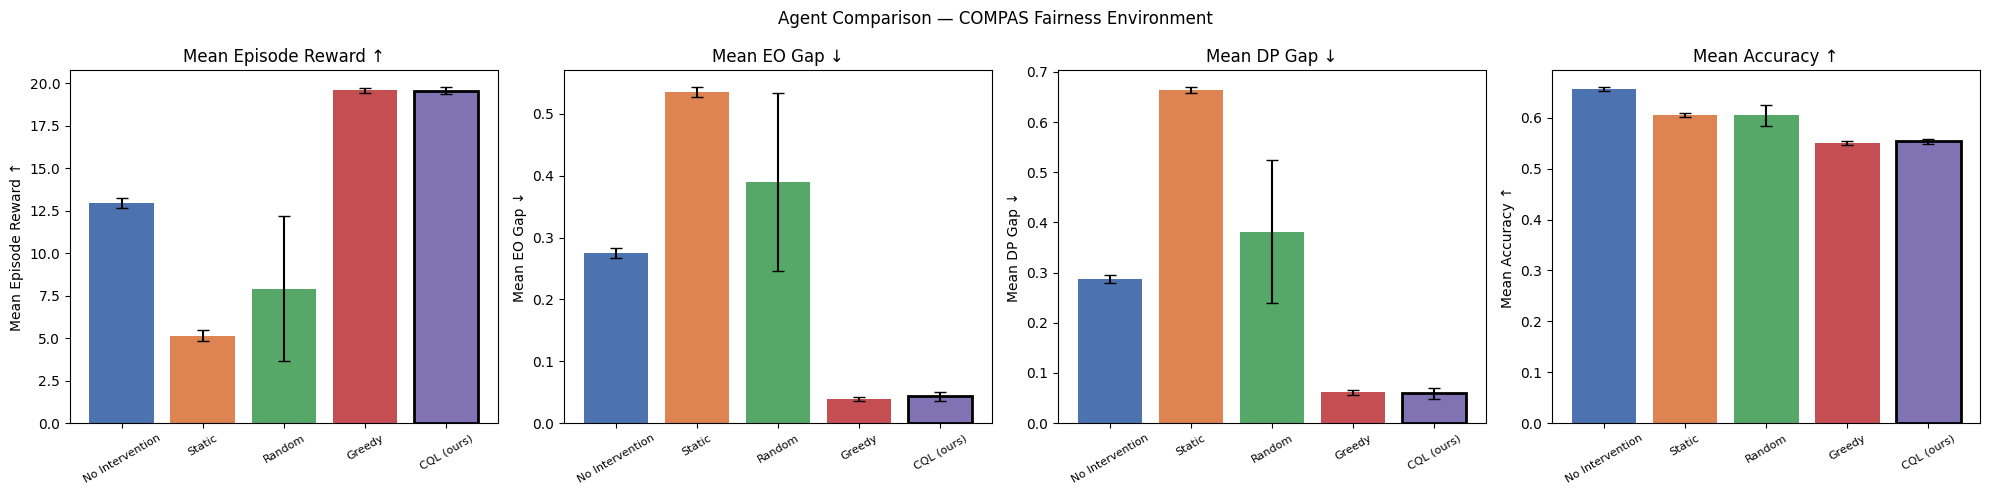

Saved baseline_comparison.png


In [29]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
names  = list(eval_results.keys())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

for ax, key, label in zip(axes,
                           ["rewards", "eo_gap", "dp_gap", "acc"],
                           ["Mean Episode Reward ↑", "Mean EO Gap ↓", "Mean DP Gap ↓", "Mean Accuracy ↑"]):
    means = [np.mean(eval_results[n][key]) for n in names]
    stds  = [np.std(eval_results[n][key])  for n in names]
    bars  = ax.bar(names, means, yerr=stds, color=colors, capsize=4)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    for bar, name in zip(bars, names):
        if name == "CQL (ours)":
            bar.set_edgecolor("black")
            bar.set_linewidth(2.0)

plt.suptitle("Agent Comparison — COMPAS Fairness Environment", fontsize=12)
plt.tight_layout()
plt.savefig("plots/baseline_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved baseline_comparison.png")


## Fairness–Accuracy Trade-off (varying λ)

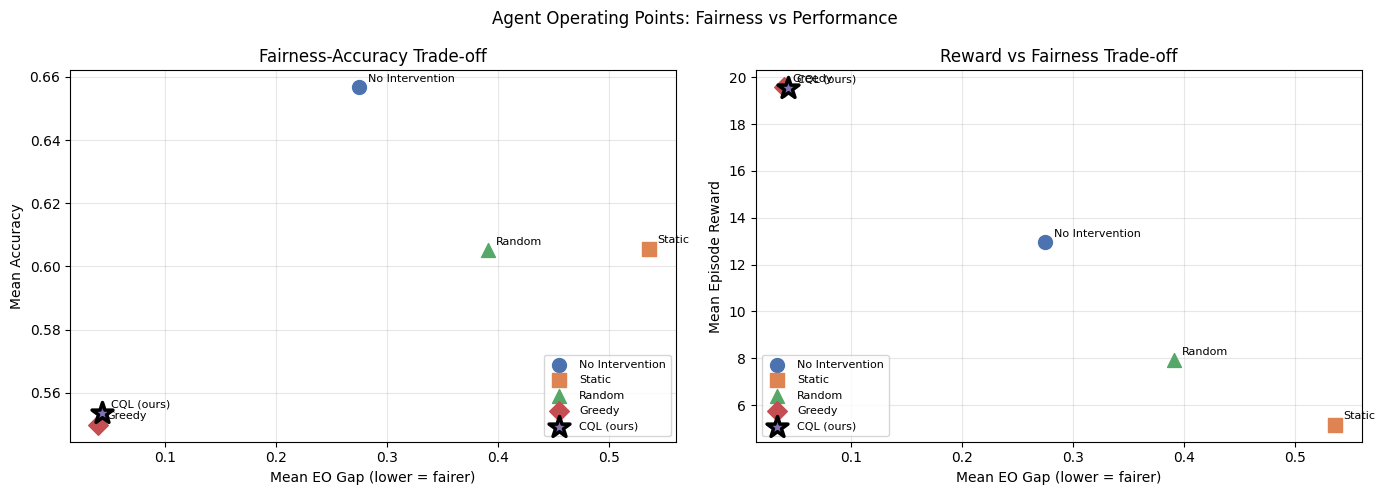

Fairness-Accuracy Summary:
  Agent                |   EO Gap |  Accuracy |   Reward
---------------------------------------------------------
  No Intervention      |    0.275 |     0.657 |   12.947
  Static               |    0.535 |     0.606 |    5.153
  Random               |    0.390 |     0.605 |    7.918
  Greedy               |    0.039 |     0.550 |   19.572
  CQL (ours)           |    0.043 |     0.554 |   19.554


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names   = list(eval_results.keys())
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
markers = ["o", "s", "^", "D", "*"]
sizes   = [100, 100, 100, 100, 250]

for ax, y_key, y_label, title in [
    (axes[0], "acc",     "Mean Accuracy",       "Fairness-Accuracy Trade-off"),
    (axes[1], "rewards", "Mean Episode Reward",  "Reward vs Fairness Trade-off"),
]:
    for name, color, marker, size in zip(names, colors, markers, sizes):
        eo_val  = np.mean(eval_results[name]["eo_gap"])
        y_val   = np.mean(eval_results[name][y_key])
        ec      = "black" if name == "CQL (ours)" else color
        lw      = 2.5    if name == "CQL (ours)" else 1.0
        ax.scatter(eo_val, y_val, color=color, marker=marker,
                   s=size, label=name, zorder=5, linewidths=lw, edgecolors=ec)
        ax.annotate(name, (eo_val, y_val), textcoords="offset points",
                    xytext=(6, 4), fontsize=8)
    ax.set_xlabel("Mean EO Gap (lower = fairer)")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    leg_loc = "lower right" if y_key == "acc" else "lower left"
    ax.legend(fontsize=8, loc=leg_loc)
    ax.grid(alpha=0.3)

plt.suptitle("Agent Operating Points: Fairness vs Performance", fontsize=12)
plt.tight_layout()
plt.savefig("plots/fairness_accuracy_tradeoff.png", dpi=120)
plt.show()

print("Fairness-Accuracy Summary:")
header = "  {:<20} | {:>8} | {:>9} | {:>8}".format("Agent", "EO Gap", "Accuracy", "Reward")
print(header)
print("-" * 57)
for name in names:
    eo  = np.mean(eval_results[name]["eo_gap"])
    acc = np.mean(eval_results[name]["acc"])
    rew = np.mean(eval_results[name]["rewards"])
    print("  {:<20} | {:8.3f} | {:9.3f} | {:8.3f}".format(name, eo, acc, rew))


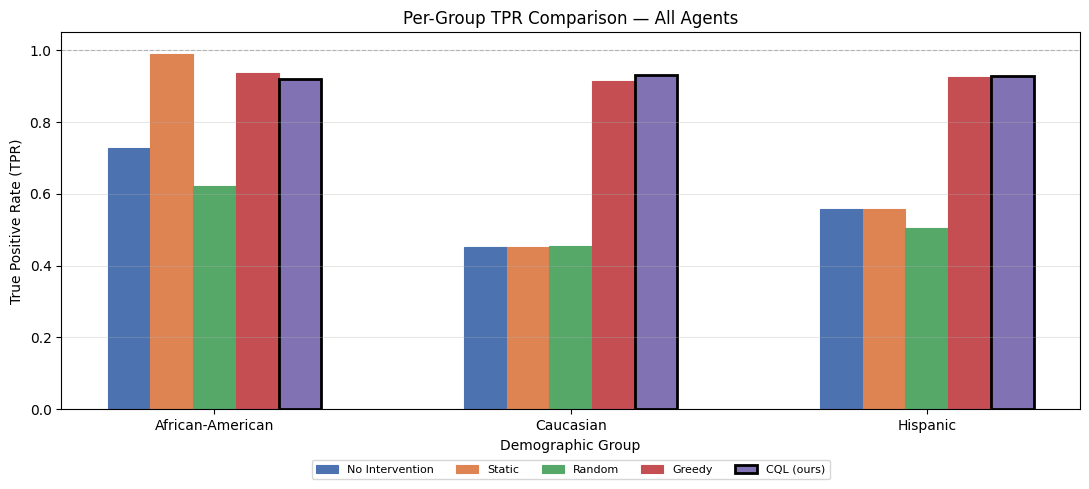

EO Gap (max TPR - min TPR across groups):
  No Intervention     : 0.275
  Static              : 0.535
  Random              : 0.168
  Greedy              : 0.021
  CQL (ours)          : 0.012 ◀ ours


In [31]:
## Per-Group TPR Comparison

import numpy as np
import matplotlib.pyplot as plt

groups_label = ["African-American", "Caucasian", "Hispanic"]
tpr_keys     = ["tpr_AA", "tpr_CA", "tpr_HI"]
agent_names  = list(eval_results.keys())
colors       = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

x     = np.arange(len(groups_label))
width = 0.12
n     = len(agent_names)
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * width

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, color) in enumerate(zip(agent_names, colors)):
    tpr_means = [np.mean(eval_results[name][k]) for k in tpr_keys]
    lw  = 2.0 if name == "CQL (ours)" else 0.8
    ec  = "black" if name == "CQL (ours)" else color
    bars = ax.bar(x + offsets[i], tpr_means, width, label=name,
                  color=color, edgecolor=ec, linewidth=lw)

ax.set_xlabel("Demographic Group")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("Per-Group TPR Comparison — All Agents")
ax.set_xticks(x)
ax.set_xticklabels(groups_label)
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=len(agent_names), frameon=True)
plt.tight_layout()
plt.savefig("plots/per_group_tpr.png", dpi=120, bbox_inches="tight")
plt.show()

# Print EO gap (max-min TPR) per agent
print("EO Gap (max TPR - min TPR across groups):")
for name in agent_names:
    tpr_vals = [np.mean(eval_results[name][k]) for k in tpr_keys]
    eo = max(tpr_vals) - min(tpr_vals)
    marker = " ◀ ours" if name == "CQL (ours)" else ""
    print(f"  {name:<20}: {eo:.3f}{marker}")


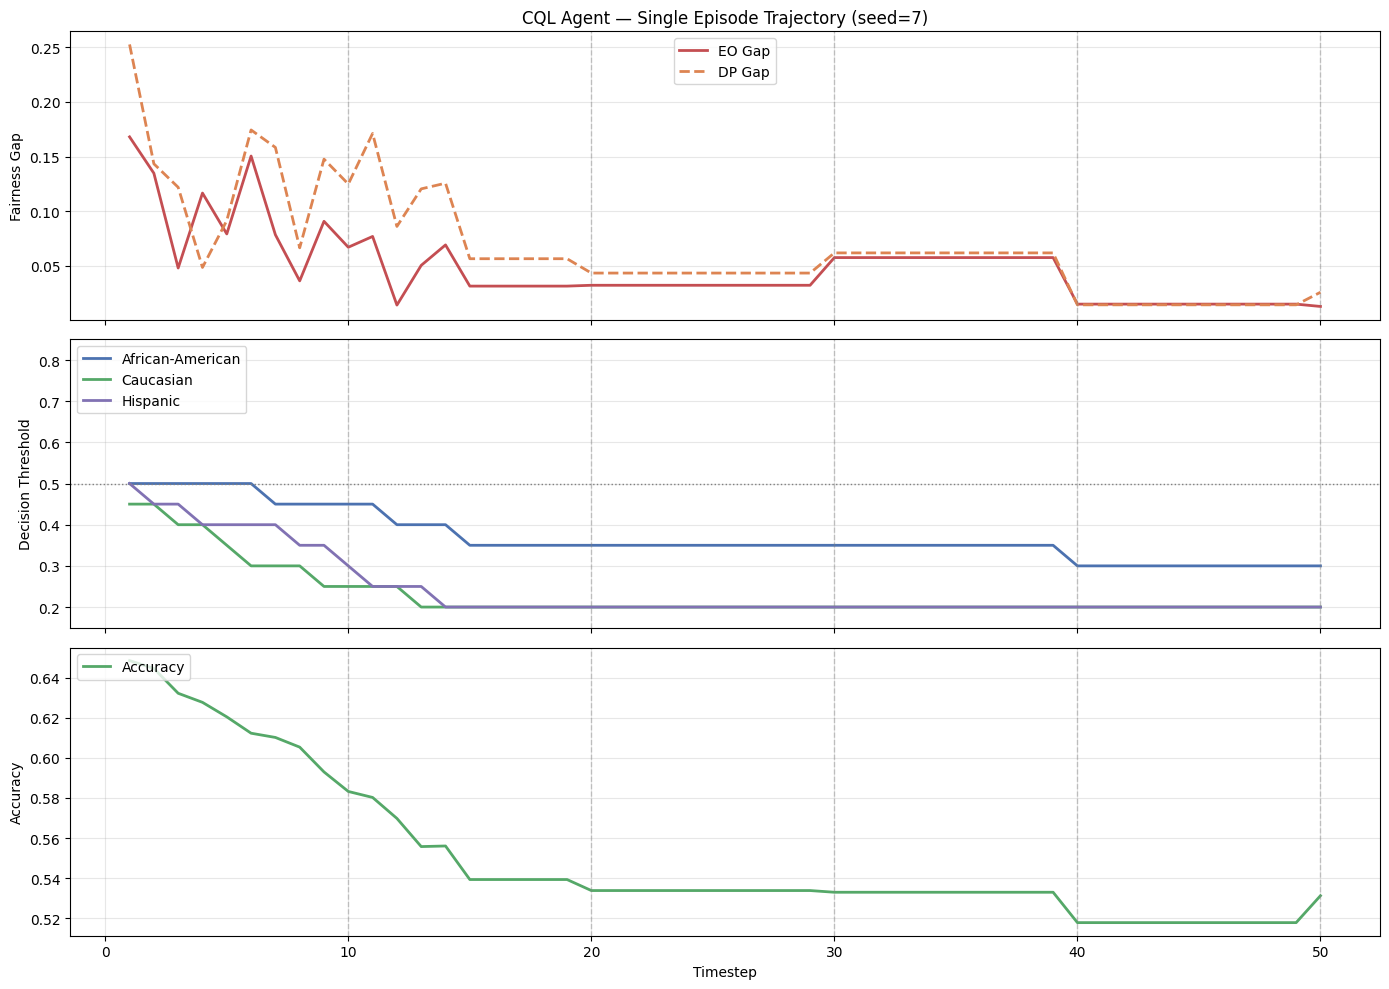

Saved trajectory_demonstration.png

First 10 steps of CQL trajectory:
Step |     Action |  EO Gap |  DP Gap | Accuracy |  Reward
------------------------------------------------------------
   1 |    CA thr- |   0.168 |   0.253 |    0.649 |  0.3243
   2 |    HI thr- |   0.135 |   0.143 |    0.645 |  0.3440
   3 |    CA thr- |   0.048 |   0.122 |    0.632 |  0.3941
   4 |    HI thr- |   0.117 |   0.048 |    0.628 |  0.3581
   5 |    CA thr- |   0.079 |   0.091 |    0.620 |  0.3799
   6 |    CA thr- |   0.150 |   0.174 |    0.612 |  0.3401
   7 |    AA thr- |   0.078 |   0.158 |    0.610 |  0.3859
   8 |    HI thr- |   0.036 |   0.066 |    0.605 |  0.4109
   9 |    CA thr- |   0.091 |   0.148 |    0.593 |  0.3775
  10 |    HI thr- |   0.067 |   0.125 |    0.583 |  0.3842


In [32]:
# Run one CQL episode and record step-by-step actions, thresholds, and fairness metrics

demo_env = FairnessEnv(group_probs_dict, max_steps=50, seed=7)
state = demo_env.reset()
last_info = None

traj = {"step": [], "action": [], "eo_gap": [], "dp_gap": [], "accuracy": [],
        "thr_AA": [], "thr_CA": [], "thr_HI": [], "reward": []}

ACTION_LABELS = {
    0: "No-op",   1: "AA thr+", 2: "AA thr-",
    3: "CA thr+", 4: "CA thr-", 5: "HI thr+",
    6: "HI thr-", 7: "All thr+", 8: "All thr-"
}

done = False
while not done:
    action = agent.select_action(state)
    state, reward, done, info = demo_env.step(action)
    m = info["metrics"]
    t = info["thresholds"]
    traj["step"].append(demo_env.step_count)
    traj["action"].append(ACTION_LABELS[action])
    traj["eo_gap"].append(m["eo_gap"])
    traj["dp_gap"].append(m["dp_gap"])
    traj["accuracy"].append(m["accuracy"])
    traj["thr_AA"].append(t["African-American"])
    traj["thr_CA"].append(t["Caucasian"])
    traj["thr_HI"].append(t["Hispanic"])
    traj["reward"].append(reward)
    last_info = info

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(traj["step"], traj["eo_gap"], label="EO Gap", color="#C44E52", linewidth=2)
axes[0].plot(traj["step"], traj["dp_gap"], label="DP Gap", color="#DD8452", linewidth=2, linestyle="--")
axes[0].set_ylabel("Fairness Gap")
axes[0].set_title("CQL Agent — Single Episode Trajectory (seed=7)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(traj["step"], traj["thr_AA"], label="African-American", color="#4C72B0", linewidth=2)
axes[1].plot(traj["step"], traj["thr_CA"], label="Caucasian",        color="#55A868", linewidth=2)
axes[1].plot(traj["step"], traj["thr_HI"], label="Hispanic",         color="#8172B3", linewidth=2)
axes[1].axhline(0.5, color="grey", linestyle=":", linewidth=1)
axes[1].set_ylabel("Decision Threshold")
axes[1].set_ylim(0.15, 0.85)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(traj["step"], traj["accuracy"], label="Accuracy", color="#55A868", linewidth=2)
axes[2].set_ylabel("Accuracy")
axes[2].set_xlabel("Timestep")
axes[2].legend(loc="upper left")
axes[2].grid(alpha=0.3)

for ax in axes:
    for drift_t in range(10, 51, 10):
        ax.axvline(drift_t, color="grey", linestyle="--", alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig("plots/trajectory_demonstration.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved trajectory_demonstration.png")

# Print first 10 steps as a table
print()
print("First 10 steps of CQL trajectory:")
header = "{:>4} | {:>10} | {:>7} | {:>7} | {:>8} | {:>7}".format(
    "Step", "Action", "EO Gap", "DP Gap", "Accuracy", "Reward")
print(header)
print("-" * 60)
for i in range(min(10, len(traj["step"]))):
    print("{:>4} | {:>10} | {:>7.3f} | {:>7.3f} | {:>8.3f} | {:>7.4f}".format(
        traj["step"][i], traj["action"][i], traj["eo_gap"][i],
        traj["dp_gap"][i], traj["accuracy"][i], traj["reward"][i]))
